# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [2]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?


2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. V_reset is set lower than V_rest to represent afterhyperpolarization.

After a real neuron fires, its voltage briefly drops below the resting level before returning to normal. This makes the neuron temporarily harder to fire again. The lower reset value mimics this behavior.

2. The time constant τ controls how fast the neuron’s voltage returns to resting level when there is no input.

In simple terms, it controls how quickly the neuron “forgets” incoming signals.

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [10]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[200:800] = 16.0

# ============ Storage Arrays ============
V = np.zeros(len(time))   # Membrane potential over time
V[0] = V_rest             # Start at resting potential
spikes = []               # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change using the LIF equation
    # dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
    dV = (dt / tau) * ((V_rest - V[t]) + I_input[t])

    # TODO 2: Update the membrane potential
    # V at next time step = V at current step + dV
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    # If V[t+1] >= V_thresh:
    #   - Append time[t+1] to the spikes list
    #   - Reset V[t+1] to V_reset
    if V[t+1] >= V_thresh:
      spikes.append(time[t+1])
      V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 10 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

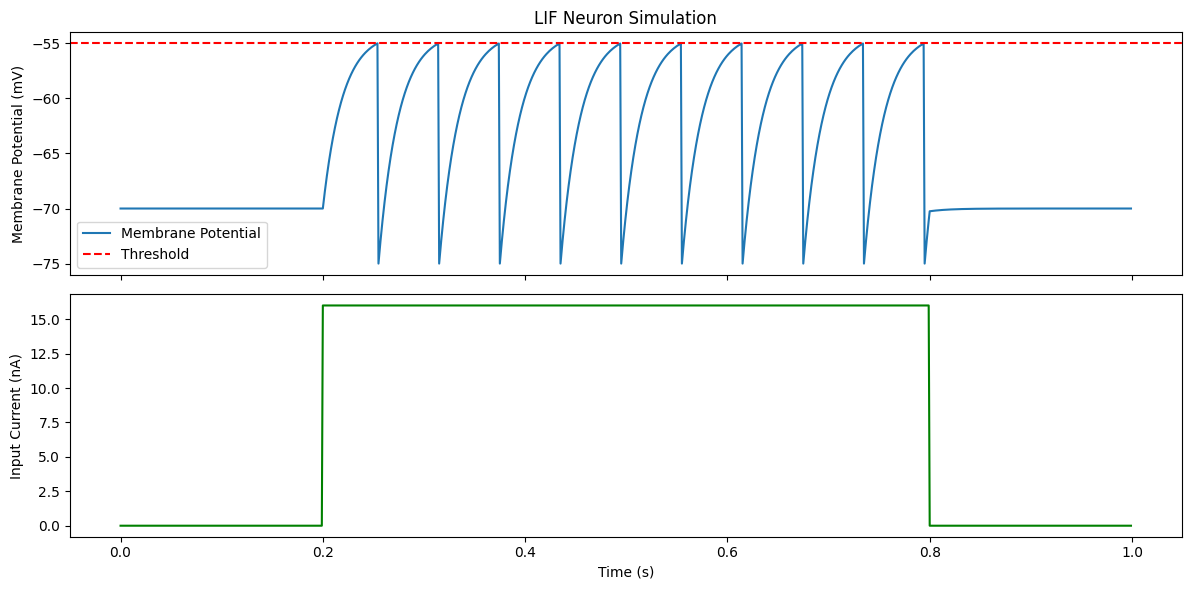

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
# - Plot V over time
# - Add a horizontal dashed line at V_thresh
#   Hint: ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, label='Input Current', color='g')

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. V curves upward, not straight.

It curves because the neuron is “leaky.” As the voltage increases, the leak pulls it back toward the resting potential. This makes the rise slow down over time instead of increasing in a straight line.

2. After the current turns off, V gradually goes back down to the resting potential.

This happens because there is no more input pushing it up, and the leak term causes the voltage to decay back to V_rest.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*

When I look at the membrane potential trace, some parts look realistic compared to real biological neurons. The voltage gradually increases when current is injected, which shows the “integrate” behavior. The neuron also resets after reaching the threshold, which matches the “fire” part of real neurons. The curved rise between spikes also looks realistic because real neurons do not increase in a straight line — they are affected by membrane leakage.

However, the model is still very simplified. In real neurons, spikes have a sharp peak and a full action potential shape, but in this simulation, the voltage just resets instantly to V_reset. There is no true spike waveform. Also, real neurons have refractory periods, ion channel dynamics, and random noise, but this model does not include those details. Overall, the simulation captures the basic integrate-and-fire behavior, but it leaves out many biological complexities.

---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [12]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # If random < value → spike (1), otherwise no spike (0)
        # Hint: np.random.rand(num_neurons) gives an array of random numbers
        # Hint: (random_array < values) gives True/False, use .astype(float)
        random_array = np.random.rand(num_neurons)
        spikes[t] = (random_array < values).astype(float)

    return spikes

**Test your function:**

In [13]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 15 spikes in 200 steps
Value 0.3 -> 50 spikes in 200 steps
Value 0.5 -> 103 spikes in 200 steps
Value 0.7 -> 138 spikes in 200 steps
Value 0.9 -> 183 spikes in 200 steps


> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [14]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # Higher values should spike at EARLIER time steps
            # spike_time = int((1 - values[i]) * (num_steps - 1))
            # This maps value=1.0 → time=0 and value≈0 → time≈num_steps
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

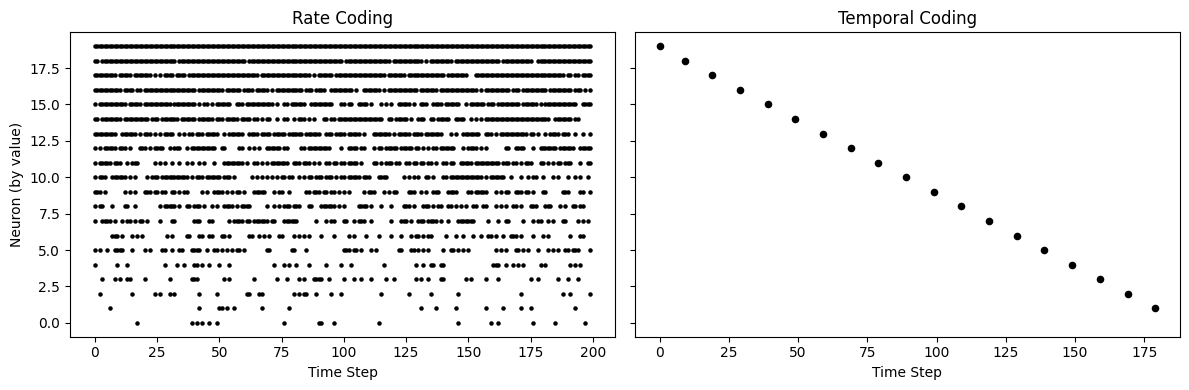

In [15]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
# Left subplot: raster plot for rate coding
# Right subplot: raster plot for temporal coding
# Label axes: x = 'Time Step', y = 'Neuron (by value)'
# Title each subplot: 'Rate Coding' and 'Temporal Coding'
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ---- Left: Rate coding raster ----
times, neurons = np.where(rate_spks == 1)
ax1.scatter(times, neurons, s=5, color='black')
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# ---- Right: Temporal coding raster ----
times, neurons = np.where(temp_spks == 1)
ax2.scatter(times, neurons, s=20, color='black')
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()


> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. In rate coding, the exact timing of spikes is lost. We do not know when each spike happened, only how many occurred over time.

What is preserved is the overall strength of the signal. Higher values produce more spikes, so the firing rate represents the intensity of the original input.

2. In temporal coding, higher values spike earlier. This means a downstream neuron can make a decision as soon as it detects the first spike.

In rate coding, the neuron must wait and count spikes over time to estimate the rate. Temporal coding can therefore allow faster decision-making.

3. One example is sound localization. The brain detects very small differences in the time a sound reaches the left and right ears. These tiny timing differences help determine where the sound is coming from. In this case, timing is more important than how often neurons fire.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*

When I compare the two raster plots, I notice that in rate coding, neurons fire many spikes over time, and stronger values produce denser spike patterns. In temporal coding, each neuron usually fires only once, and higher values spike earlier than lower values. The information in temporal coding is concentrated at the beginning, while rate coding spreads information across time.

For a system that needs to react quickly, temporal coding would be better. A downstream neuron can make a decision as soon as it detects the first spike, without waiting to count many spikes. This allows faster responses.

For precise measurements, rate coding may be better because counting spikes over time can give a more stable and reliable estimate of signal strength.

The brain likely uses both strategies because different tasks require different trade-offs. Some circuits need speed, like detecting danger or sound direction, while others need accuracy and stability, such as measuring stimulus intensity. Using both strategies allows the brain to balance speed and precision depending on the situation.

---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [62]:
# Network parameters
N = 5  # Number of neurons
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i, j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 22.0   # Neuron 0 → 2 (excitatory)
weights[1, 3] = 22.0   # Neuron 1 → 3 (excitatory)
weights[2, 4] = 18.0   # Neuron 2 → 4 (excitatory)
weights[3, 4] = 18.0   # Neuron 3 → 4 (excitatory)

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 22.0   # Neuron 0 gets current
# I_ext[150:350, 1] = 18.0   # Neuron 1 gets current (slightly offset)
I_ext[100:400, 1] = 22.0

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]  # Spike times per neuron
just_spiked = np.zeros(N, dtype=bool)  # Track spikes at current step

prev_spiked = np.zeros(N, dtype=bool)       # Spikes at previous step
syn_tau = 0.02  # 10 ms synaptic decay time constant
I_syn = np.zeros(N)  # synaptic current for each neuron
V_thresh_out = -53.0  # harder threshold than -55 (less spikes)



# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked[:] = False
    # 1) decay synaptic current each step
    I_syn *= np.exp(-dt / syn_tau)

    # 2) add new synaptic input from spikes at previous step
    for j in range(N):
        if prev_spiked[j]:
            I_syn += weights[j, :]   # add outputs of neuron j to all targets

    for n in range(N):
        # TODO 9: Calculate total input current for neuron n
        # Start with external current, then add synaptic input
        # Synaptic input: for each neuron j that spiked at the previous step,
        #   add weights[j, n] to the current
        # Hint: Check if time_net[t] is close to any time in spike_log[j]
        #   OR simpler: use a 'prev_spiked' approach
        #I_total = I_ext[t, n]
        I_total = I_ext[t, n] + I_syn[n]

        #for j in range(N):
        #    if prev_spiked[j]:
        #        I_total += weights[j, n]


        # TODO 10: Update membrane potential (same LIF equation as Part A)
        dV = (dt / tau) * ((V_rest - V_net[t, n]) + I_total)
        V_net[t+1, n] = V_net[t, n] + dV

        # TODO 11: Check for spike, reset, and record
        # If spiked, append time_net[t+1] to spike_log[n]
        # and set just_spiked[n] = True
        th = V_thresh_out if n == 4 else V_thresh
        if V_net[t+1, n] >= th:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked[n] = True
    # Update prev_spiked for next time step
    prev_spiked[:] = just_spiked
# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 11 spikes
Neuron 1: 11 spikes
Neuron 2: 5 spikes
Neuron 3: 5 spikes
Neuron 4: 2 spikes


> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

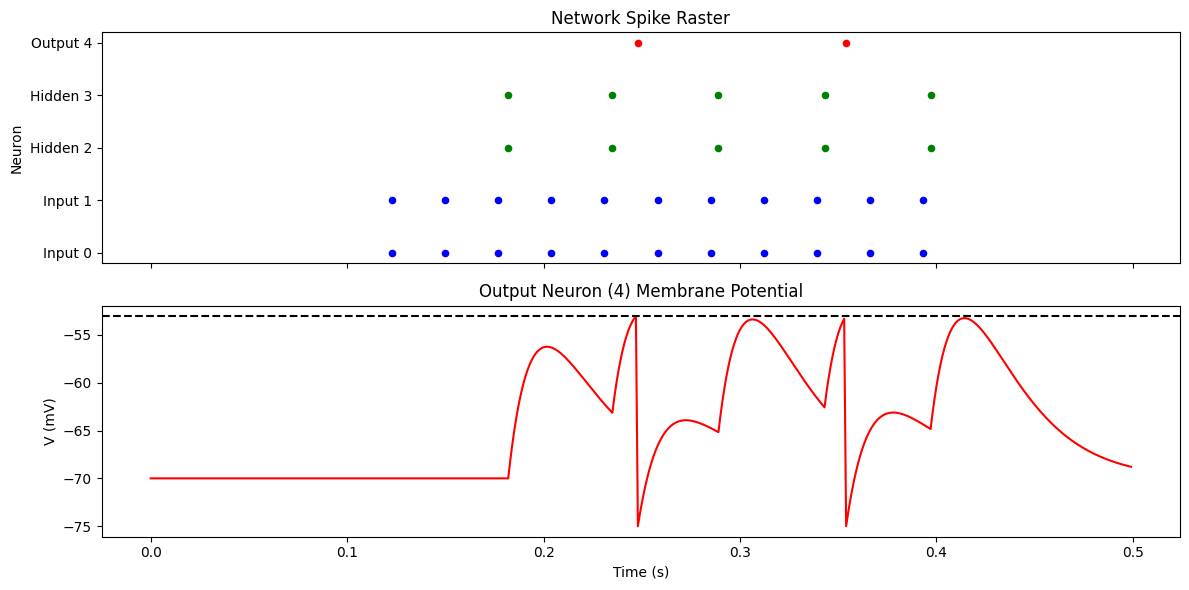

In [63]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
# For each neuron n, plot its spike times as dots at y = n
# Use different colors: blue for input (0,1), green for hidden (2,3), red for output (4)
# Hint: ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color='blue')
for n in range(N):
    if n in [0, 1]:  # Input neurons
        color = 'blue'
    elif n in [2, 3]:  # Hidden neurons
        color = 'green'
    else:  # Output neuron (4)
        color = 'red'

    ax1.scatter(spike_log[n], [n] * len(spike_log[n]),
                s=20, color=color)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron (4) membrane potential
ax2.plot(time_net, V_net[:, 4], color='red', label='Neuron 4')
ax2.axhline(y=V_thresh_out, color='black', linestyle='--', label='Threshold')

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No, the output neuron does not fire at the same rate as the input neurons.

The input neurons receive direct external current, so they fire more consistently. The output neuron only fires when it receives enough combined synaptic input from the hidden neurons. Because its firing depends on other neurons and it has a higher threshold, it fires less often.

2. Synaptic weights control how strongly one neuron influences another.

* Larger weights mean stronger excitation, making the receiving neuron more likely to fire.

* Smaller weights mean weaker influence, making spikes less likely.

If you doubled the weights, hidden and output neurons would fire more often, possibly too much. If you halved the weights, they might fire less or even stop firing completely.

3. If weights[3, 4] were negative, neuron 3 would inhibit neuron 4 instead of exciting it.

This would reduce the likelihood that neuron 4 fires. If the inhibition is strong enough, neuron 4 might fire much less or not at all. This would simulate inhibitory connections in the brain, which help control and balance neural activity.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment 1: Threshold Sensitivity
**Parameter changed:**  Change V_thresh from -55 to -50, then -60

**Expected result:**  
* When V_thresh = -50 mV (higher threshold, less negative):
The neuron will fire less often or may not fire at all.
This is because the membrane potential must rise higher to reach threshold, making it harder to trigger a spike.

* When V_thresh = -60 mV (lower threshold, more negative):
The neuron will fire more often.
Since the threshold is easier to reach, spikes occur more frequently.

V_thresh = -55.0 mV  ->  spikes: 10
V_thresh = -50.0 mV  ->  spikes: 0
V_thresh = -60.0 mV  ->  spikes: 24


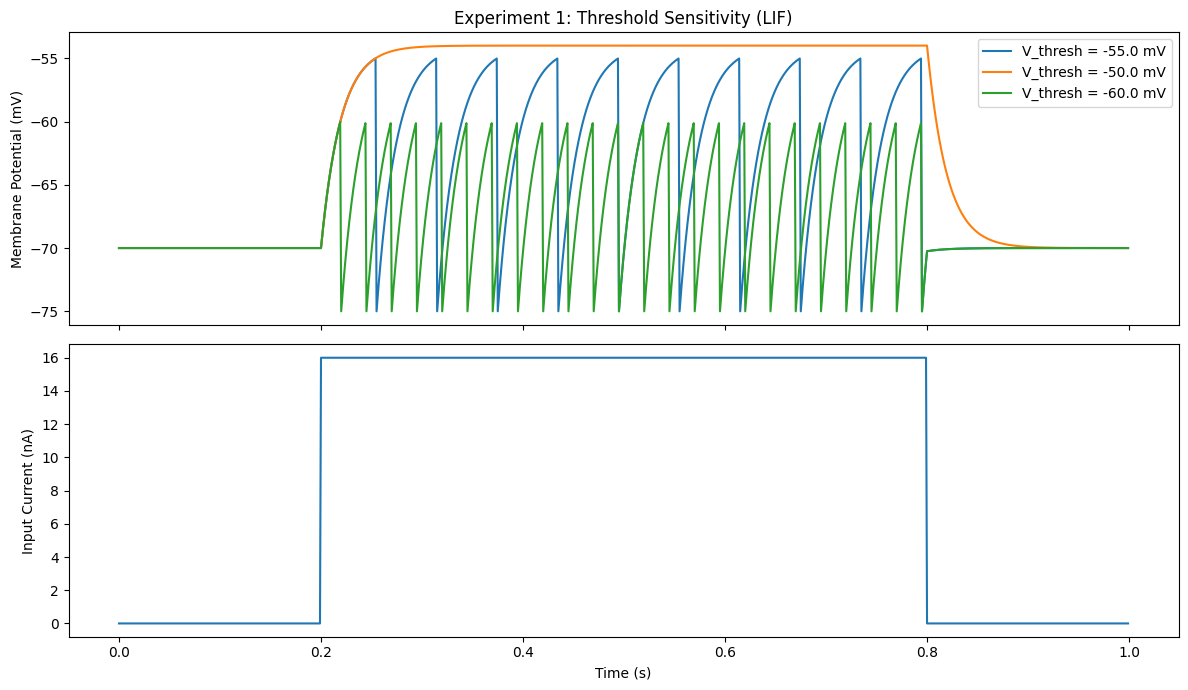

In [64]:
# Experiment code here
# ============ Simulation Parameters ============
dt = 0.001          # 1 ms
T  = 1.0            # 1 second
time = np.arange(0, T, dt)

# ============ Neuron Parameters (base) ============
V_rest  = -70.0     # mV
V_reset = -75.0     # mV
tau     = 0.020     # 20 ms
C       = 1.0       # normalized

# ============ Input Current ============
# Use the same working input you used before (16 gives spikes)
I_input = np.zeros(len(time))
I_input[200:800] = 16.0

def run_lif(V_thresh, I_input, time, dt, V_rest, V_reset, tau, C):
    """Run one LIF simulation and return voltage trace + spike times."""
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t in range(len(time) - 1):
        # Normalized discrete LIF update (matches your earlier working version)
        dV = (dt / tau) * ((V_rest - V[t]) + (I_input[t] / C))
        V[t+1] = V[t] + dV

        if V[t+1] >= V_thresh:
            spikes.append(time[t+1])
            V[t+1] = V_reset

    return V, np.array(spikes)

# ============ Experiment 1: Threshold Sensitivity ============
thresholds = [-55.0, -50.0, -60.0]  # baseline, harder, easier
results = {}

for thr in thresholds:
    V_trace, spk = run_lif(thr, I_input, time, dt, V_rest, V_reset, tau, C)
    results[thr] = (V_trace, spk)
    print(f"V_thresh = {thr:>5.1f} mV  ->  spikes: {len(spk)}")

# ============ Visualization ============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Voltage traces
for thr in thresholds:
    V_trace, spk = results[thr]
    ax1.plot(time, V_trace, label=f"V_thresh = {thr} mV")

ax1.set_ylabel("Membrane Potential (mV)")
ax1.set_title("Experiment 1: Threshold Sensitivity (LIF)")
ax1.legend()

# Input current
ax2.plot(time, I_input)
ax2.set_ylabel("Input Current (nA)")
ax2.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

**What happened:**  
When the threshold was changed from -55 mV to -50 mV, the neuron fired fewer spikes (or possibly none).

When the threshold was changed from -55 mV to -60 mV, the neuron fired more spikes.

**Why it makes sense:**  
The threshold determines how easily the neuron can fire.

* A higher threshold (less negative, like -50 mV) means the membrane potential must rise more to trigger a spike, so firing becomes less frequent.

* A lower threshold (more negative, like -60 mV) makes it easier to reach the threshold, so the neuron fires more often.

This matches the idea that lowering the threshold makes the neuron more excitable, while raising it makes the neuron less excitable.

### Experiment 4: Noisy Input
**Parameter changed:**  Add noise: I_noisy = 15.0 + np.random.randn(len(time)) * 5.0.

**Expected result:**  The spike pattern will become irregular instead of regular.

With constant input, spikes occur at fairly regular intervals.
With noisy input, the membrane potential fluctuates randomly, so spikes happen at unpredictable times.

Some spikes may occur closer together, while others may be farther apart. The firing rate may also vary slightly from run to run because the noise is random.

Neuron fired 5 spikes


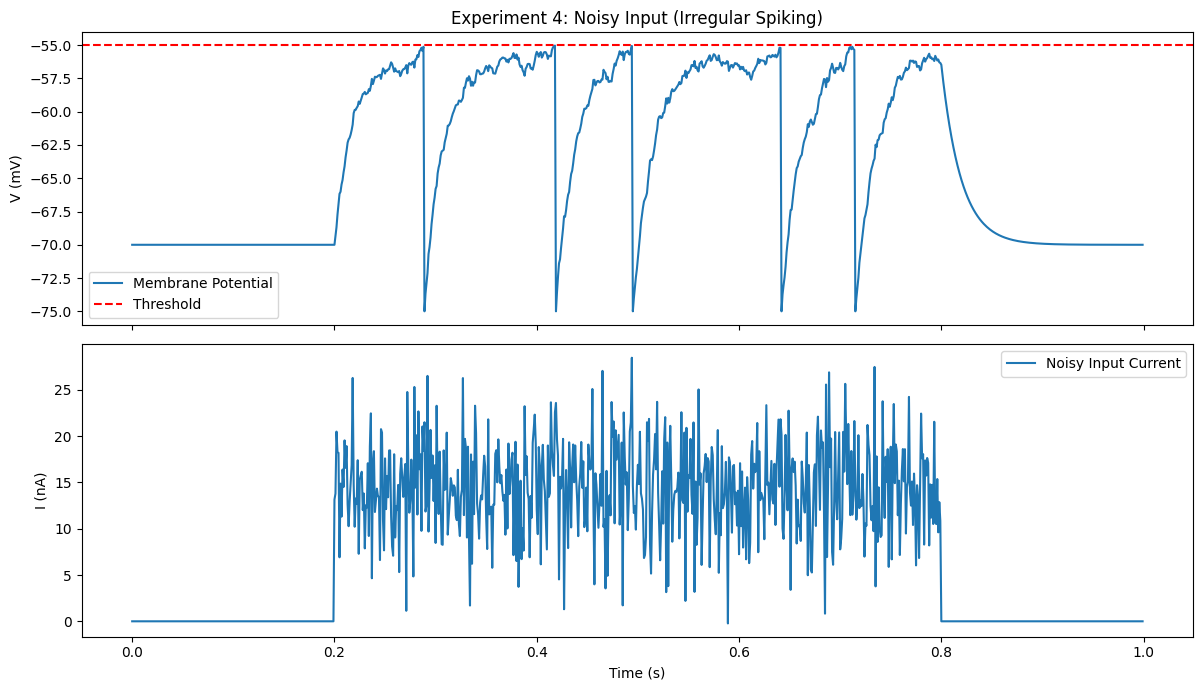

In [65]:
# Experiment code here
# ============ Simulation Parameters ============
dt = 0.001          # 1 ms
T  = 1.0            # 1 second
time = np.arange(0, T, dt)

# ============ Neuron Parameters ============
V_rest   = -70.0    # mV
V_thresh = -55.0    # mV
V_reset  = -75.0    # mV
tau      = 0.020    # 20 ms
C        = 1.0      # normalized

# ============ Noisy Input Current ============
# Baseline current + Gaussian noise
np.random.seed(0)  # (optional) makes results repeatable
I_noisy = 15.0 + np.random.randn(len(time)) * 5.0

# Optional: apply current only during 200ms to 800ms (like earlier sections)
I_mask = np.zeros(len(time))
I_mask[200:800] = 1.0
I_noisy = I_noisy * I_mask

# ============ Storage Arrays ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time) - 1):
    # Normalized LIF update (same style you used before)
    dV = (dt / tau) * ((V_rest - V[t]) + (I_noisy[t] / C))
    V[t+1] = V[t] + dV

    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

# ============ Visualization ============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Membrane potential
ax1.plot(time, V, label="Membrane Potential")
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.set_ylabel("V (mV)")
ax1.set_title("Experiment 4: Noisy Input (Irregular Spiking)")
ax1.legend()

# Input current
ax2.plot(time, I_noisy, label="Noisy Input Current")
ax2.set_ylabel("I (nA)")
ax2.set_xlabel("Time (s)")
ax2.legend()

plt.tight_layout()
plt.show()

**What happened:**  

When noise was added to the input current, the spike pattern became irregular. The spikes were no longer evenly spaced in time. The membrane potential trace also looked more jagged and fluctuated up and down instead of rising smoothly toward the threshold.

**Why it makes sense:**  

The random noise causes the input current to change unpredictably at each time step. Sometimes the noise pushes the membrane potential closer to threshold faster, causing earlier spikes. Other times it reduces the effective input, delaying spikes.

This matches real biological neurons, which receive noisy signals from many other neurons, making their firing patterns less regular and more variable.

### Experiment 5: Network Inhibition


**Parameter changed:**  Set weights[3, 4] = -8.0

**Expected result:**  The output neuron (4) will fire less often, or possibly stop firing completely.

Because neuron 3 now sends negative current to neuron 4, it reduces neuron 4’s membrane potential instead of increasing it. This makes it harder for neuron 4 to reach threshold.

If inhibition is strong enough, neuron 4 may not fire at all, even if neuron 2 is excitatory.

Neuron 0: 11 spikes
Neuron 1: 11 spikes
Neuron 2: 5 spikes
Neuron 3: 5 spikes
Neuron 4: 0 spikes


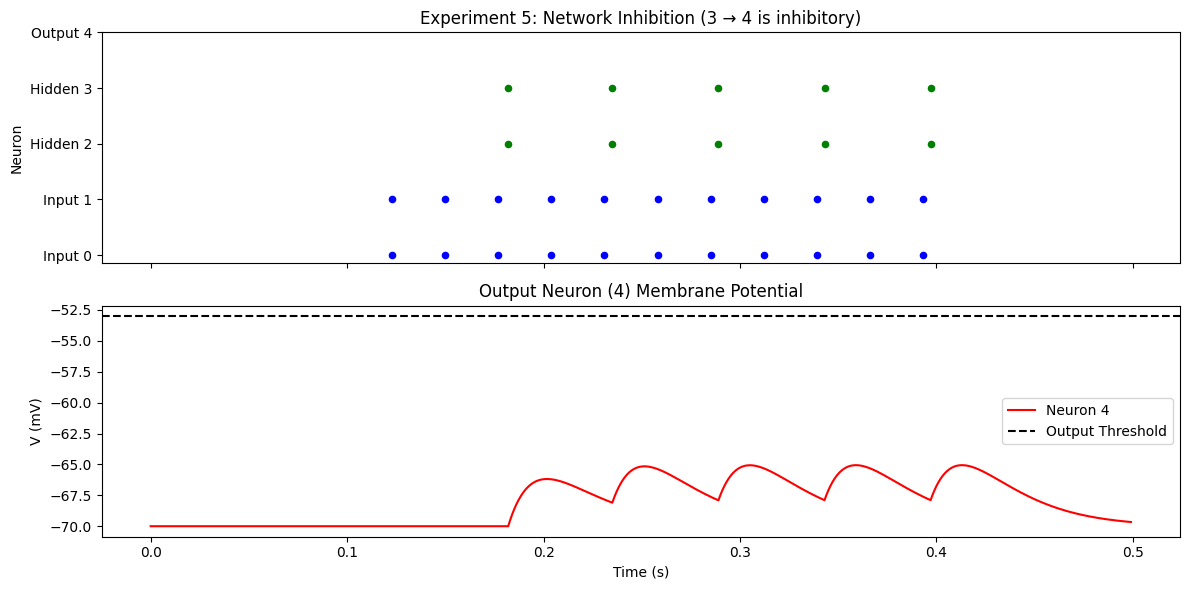

In [66]:
# Experiment code here
# ============ Shared Neuron Parameters ============
dt = 0.001
V_rest   = -70.0
V_thresh = -55.0
V_reset  = -75.0
tau      = 0.020

# ============ Network parameters ============
N = 5
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# ============ Weight matrix ============
weights = np.zeros((N, N))
weights[0, 2] = 22.0     # 0 -> 2 (exc)
weights[1, 3] = 22.0     # 1 -> 3 (exc)
weights[2, 4] = 18.0     # 2 -> 4 (exc)
weights[3, 4] = -8.0     # 3 -> 4 (INHIBITORY)  <-- Experiment 5 change

# ============ External input (to 0 and 1 only) ============
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 22.0
I_ext[100:400, 1] = 22.0

# ============ Synaptic trace settings ============
syn_tau = 0.02
I_syn = np.zeros(N)

# ============ Storage ============
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]
just_spiked = np.zeros(N, dtype=bool)
prev_spiked = np.zeros(N, dtype=bool)

# Optional: slightly harder output threshold (keeps output low)
V_thresh_out = -53.0

# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked[:] = False

    # Decay synaptic currents
    I_syn *= np.exp(-dt / syn_tau)

    # Add synaptic input from spikes at previous step
    for j in range(N):
        if prev_spiked[j]:
            I_syn += weights[j, :]

    for n in range(N):
        # Total current
        I_total = I_ext[t, n] + I_syn[n]

        # LIF update (normalized form)
        dV = (dt / tau) * ((V_rest - V_net[t, n]) + I_total)
        V_net[t+1, n] = V_net[t, n] + dV

        # Spike check (output neuron has its own threshold)
        th = V_thresh_out if n == 4 else V_thresh
        if V_net[t+1, n] >= th:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked[n] = True

    prev_spiked[:] = just_spiked

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

# ============ Visualization ============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Raster plot
for n in range(N):
    if n in [0, 1]:
        color = 'blue'
    elif n in [2, 3]:
        color = 'green'
    else:
        color = 'red'
    ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=20, color=color)

ax1.set_ylabel('Neuron')
ax1.set_title('Experiment 5: Network Inhibition (3 → 4 is inhibitory)')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# Output neuron membrane potential
ax2.plot(time_net, V_net[:, 4], color='red', label='Neuron 4')
ax2.axhline(y=V_thresh_out, color='black', linestyle='--', label='Output Threshold')
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')
ax2.legend()

plt.tight_layout()
plt.show()

**What happened:**  

When weights[3, 4] was set to a negative value, the output neuron (4) fired fewer spikes, or in some cases stopped firing completely. Even though neuron 2 was still excitatory, the inhibitory input from neuron 3 reduced the total current reaching neuron 4, making it harder to reach threshold.

**Why it makes sense:**  

A negative synaptic weight represents inhibition. When neuron 3 spikes, it now subtracts current from neuron 4 instead of adding to it. This lowers neuron 4’s membrane potential and prevents it from firing as easily.

In real neural circuits, inhibition helps balance excitation and prevents neurons from becoming overactive. This experiment demonstrates how inhibitory connections regulate and control network activity.

---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*

**How changing τ affects firing behavior**

* Smaller τ → faster leak. The membrane potential decays quickly, so the neuron has less time to build up charge and may fire less often.

* Larger τ → slower leak. The neuron holds onto charge longer, making it easier to reach threshold and fire more.

In simple terms:
Small τ = short memory.
Large τ = long memory.

**What biological property this represents**

τ represents how well a neuron can hold and integrate electrical charge. Different types of neurons in the brain have different time constants — some respond quickly and briefly, while others integrate inputs over longer periods before firing.

### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:*

**Comparison of Rate Coding and Temporal Coding**

Rate coding preserved more information about the overall strength of the original signal. Because spike count increases with input value, it gives a stable and reliable representation of intensity over time.

Temporal coding preserved information about when a signal is strong. Higher values produced earlier spikes, but since most neurons spike only once, less detail about exact magnitude is preserved compared to rate coding.

**Why the brain might use both**

The brain likely uses both strategies because different tasks require different advantages:

* Temporal coding is fast. A neuron can make a decision as soon as it detects the first spike. This is useful for rapid reactions, like detecting danger or locating sound.

* Rate coding is more stable and precise. Counting spikes over time reduces noise and gives a more reliable estimate of signal strength.

Using both allows the brain to balance speed and accuracy depending on the situation.


### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:*

**What happened in the mini SNN**

When spikes propagated through the layers:

* Input neurons (0, 1) fired first because they received external current.

* Hidden neurons (2, 3) fired next after receiving excitatory synaptic input from the inputs.

* The output neuron (4) fired last and least because it depended on the combined input from the hidden neurons and had a higher threshold.

As spikes moved forward, their influence depended on the synaptic weights. Stronger weights increased firing in the next layer, while weaker or inhibitory weights reduced it.

**How this relates to real neural circuits**

This is similar to real brain circuits, where information flows through layers of neurons. Sensory neurons activate intermediate neurons, which then activate higher-level neurons.

Each layer transforms the signal, and synaptic strengths determine how strongly information is passed forward. Inhibition also plays a role in controlling activity and preventing overexcitation.

So the mini SNN models how signals are integrated, modified, and filtered as they move through biological neural networks.

### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:*

**What the LIF model captures well**

* Integrate-and-fire behavior: It models how neurons accumulate input over time and fire when a threshold is reached.

* Membrane leak: It includes the natural decay of membrane potential back toward resting value.

* Refractory-like reset: After a spike, the voltage resets, mimicking how real neurons briefly recover before firing again.

* Basic excitatory/inhibitory effects: Positive and negative weights represent excitation and inhibition.

So it captures the core electrical behavior of spiking neurons in a simple way.

**What the LIF model misses**

* Dendrites: Real neurons have complex dendritic trees that process inputs differently depending on location. LIF treats the neuron as a single point.

* Neurotransmitters: It does not model chemical signaling or different receptor types (e.g., AMPA, NMDA, GABA).

* Morphology: Real neurons have varied shapes that affect signal timing and integration.

* Spike adaptation: Real neurons often change their firing rate over time, but basic LIF does not include this.

* Ion channel dynamics: Real action potentials involve complex voltage-gated ion channels, which LIF simplifies into a threshold-and-reset rule.

### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:*

One thing that stood out to me is how much timing matters in biological neural computation. Before doing these simulations, it was easy to think of neurons as just “adding numbers and firing,” similar to artificial neural networks. But seeing how small changes in timing, thresholds, or synaptic decay can dramatically change firing patterns shows that biological neurons are highly dynamic systems, not just simple weighted sums.

The fact that information can be encoded not only in how many spikes occur (rate coding), but also in when they occur (temporal coding), changed how I think about artificial intelligence. Most traditional AI models focus on static values and averages, while biological systems use precise timing and continuous interaction over time.

It also became clear how important inhibition and balance are. A small negative weight can completely reshape network behavior. That highlights how real intelligence may depend more on dynamic balance and timing than just increasing model size or stacking more layers.

---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.